## **1. Data Overview**

### 1.1. Data Loading

In [184]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

DOWNLOADS = Path("..") / "downloads"

# Load world map (GeoDataFrame)
world = gpd.read_file(DOWNLOADS / "world_map.zip")
print("World map columns:")
print(world.columns)
print()

# Load first dataset (forest_area_change)
forest_area_change = pd.read_csv(DOWNLOADS / "forest_area_change.csv")

print("Forest area change dataset columns:")
print(forest_area_change.columns)
print()

print("First 5 rows of forest area dataset:")
print(forest_area_change.head())

World map columns:
Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

Forest area change dataset columns:
Index(['Entity', 'Code', 'Year', 'Annual change in forest area'], dtype='str')

First 5 rows of forest area dataset:
        Entity Code  Year  Annual change in forest area
0  Afghanistan  AFG  1991                           0.0
1  Afghanistan  AFG  1992                           0.0
2  Afghanistan  AFG  1993                           0.0
3  Afghanistan  AFG  1994                           0.0
4  Afghanistan  AFG  1995                           0.0


In [185]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

DOWNLOADS = Path("..") / "downloads"

# ---- Load world map ----
world = gpd.read_file(DOWNLOADS / "world_map.zip")
print("World map loaded successfully.")
print("World columns:", world.columns)
print()

# ---- List of dataset filenames ----
datasets = [
    "forest_area_change.csv",
    "annual_deforestation.csv",
    "land_protected.csv",
    "land_degraded.csv",
    "mountain_ecosystems.csv",
]

# ---- Load and test each dataset ----
for filename in datasets:
    print(f"Testing {filename}...")
    
    df = pd.read_csv(DOWNLOADS / filename)
    
    print("Columns:", list(df.columns))
    print("Shape:", df.shape)
    print("First 3 rows:")
    print(df.head(3))
    print("-" * 50)

World map loaded successfully.
World columns: Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

Testing forest_area_change.csv...
Columns: ['Entity', 'Code', 'Year', 'Annual change in forest area']
Shape: (8680, 4)
First 3 rows:
        Entity Code  Year  Annual change in forest area
0  Afghanistan  AFG  1991                           0.0
1  Afghanistan  AFG  1992                           0.0
2  Afghanistan  AFG  1993                           0.0
--------------------------------------------------
Testing annual_deforestation.csv...
Columns: ['Entity', 'Code', 'Year', 'Deforestation']
Shape: (705, 4)
First 3 rows:
   Entity Code  Year  Deforestation
0  Africa  NaN  1990        3065370
1  Africa  NaN  2000        3590590
2  Africa

### 1.2. Unique Value Check

In [186]:
datasets = {
    "forest_area_change": pd.read_csv(DOWNLOADS / "forest_area_change.csv"),
    "annual_deforestation": pd.read_csv(DOWNLOADS / "annual_deforestation.csv"),
    "land_protected": pd.read_csv(DOWNLOADS / "land_protected.csv"),
    "land_degraded": pd.read_csv(DOWNLOADS / "land_degraded.csv"),
    "mountain_ecosystems": pd.read_csv(DOWNLOADS / "mountain_ecosystems.csv"),
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Number of unique entities:", df["Entity"].nunique())
    


forest_area_change
Number of unique entities: 248

annual_deforestation
Number of unique entities: 151

land_protected
Number of unique entities: 226

land_degraded
Number of unique entities: 135

mountain_ecosystems
Number of unique entities: 199


### 1.3 ISO3 Code Check

In [187]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Total rows:", len(df))
    print("Rows with Code NaN:", df["Code"].isna().sum())
    print("Rows with non-null Code:", df["Code"].notna().sum())


forest_area_change
Total rows: 8680
Rows with Code NaN: 420
Rows with non-null Code: 8260

annual_deforestation
Total rows: 705
Rows with Code NaN: 55
Rows with non-null Code: 650

land_protected
Total rows: 2689
Rows with Code NaN: 0
Rows with non-null Code: 2689

land_degraded
Total rows: 268
Rows with Code NaN: 26
Rows with non-null Code: 242

mountain_ecosystems
Total rows: 4975
Rows with Code NaN: 375
Rows with non-null Code: 4600


In [188]:
for name, df in datasets.items():
    print(f"\n{name}")
    codes = df["Code"].dropna().astype(str)
    print("Example codes:", codes.unique()[:10])
    print("Codes starting with OWID_:", codes.str.startswith("OWID_").sum())
    print("Codes length != 3:", (codes.str.len() != 3).sum())


forest_area_change
Example codes: <StringArray>
['AFG', 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'AIA', 'ATG', 'ARG', 'ARM']
Length: 10, dtype: str
Codes starting with OWID_: 35
Codes length != 3: 35

annual_deforestation
Example codes: <StringArray>
['DZA', 'AGO', 'ARG', 'AUS', 'AUT', 'AZE', 'BHR', 'BGD', 'BLR', 'BEL']
Length: 10, dtype: str
Codes starting with OWID_: 5
Codes length != 3: 5

land_protected
Example codes: <StringArray>
['AFG', 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'ATG', 'ARG', 'ARM', 'ABW']
Length: 10, dtype: str
Codes starting with OWID_: 72
Codes length != 3: 156

land_degraded
Example codes: <StringArray>
['DZA', 'ATG', 'ARG', 'ARM', 'AUS', 'AZE', 'BGD', 'BLR', 'BLZ', 'BEN']
Length: 10, dtype: str
Codes starting with OWID_: 2
Codes length != 3: 2

mountain_ecosystems
Example codes: <StringArray>
['AFG', 'DZA', 'ASM', 'AND', 'AGO', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE']
Length: 10, dtype: str
Codes starting with OWID_: 25
Codes length != 3: 25


### 1.4 Time Consistency

In [189]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Min year:", df["Year"].min())
    print("Max year:", df["Year"].max())


forest_area_change
Min year: 1991
Max year: 2025

annual_deforestation
Min year: 1990
Max year: 2020

land_protected
Min year: 2013
Max year: 2024

land_degraded
Min year: 2015
Max year: 2019

mountain_ecosystems
Min year: 2000
Max year: 2024


### 1.5. Duplicates per Country-Year

In [190]:
for name, df in datasets.items():
    print(f"\n{name}")
    duplicates = df.duplicated(subset=["Code", "Year"]).sum()
    print("Duplicate Code-Year pairs:", duplicates)


forest_area_change
Duplicate Code-Year pairs: 385

annual_deforestation
Duplicate Code-Year pairs: 50

land_protected
Duplicate Code-Year pairs: 0

land_degraded
Duplicate Code-Year pairs: 24

mountain_ecosystems
Duplicate Code-Year pairs: 350


In [191]:
df = datasets["forest_area_change"]

dupes = df[df.duplicated(subset=["Code", "Year"], keep=False)]
print(dupes.sort_values(["Code", "Year"]).head(20))

                                            Entity Code  Year  \
35                                          Africa  NaN  1991   
420   Ascension, Saint Helena and Tristan da Cunha  NaN  1991   
455                                           Asia  NaN  1991   
2485                                        Europe  NaN  1991   
2520                           European Union (27)  NaN  1991   
3395                         High-income countries  NaN  1991   
4410                          Low-income countries  NaN  1991   
4445                 Lower-middle-income countries  NaN  1991   
5635                                 North America  NaN  1991   
5810                                       Oceania  NaN  1991   
7210                                 South America  NaN  1991   
8225                 Upper-middle-income countries  NaN  1991   
36                                          Africa  NaN  1992   
421   Ascension, Saint Helena and Tristan da Cunha  NaN  1992   
456                      

In [192]:
for name, df in datasets.items():
    print(f"\n{name}")
    
    # keep only rows with real ISO codes
    df_clean = df.dropna(subset=["Code"])
    
    duplicates = df_clean[df_clean.duplicated(subset=["Code", "Year"], keep=False)]
    
    print("Duplicate rows (non-null Code):", len(duplicates))
    
    if len(duplicates) > 0:
        print(duplicates.sort_values(["Code", "Year"]).head(10))


forest_area_change
Duplicate rows (non-null Code): 0

annual_deforestation
Duplicate rows (non-null Code): 0

land_protected
Duplicate rows (non-null Code): 0

land_degraded
Duplicate rows (non-null Code): 0

mountain_ecosystems
Duplicate rows (non-null Code): 0


## **2. Exploring Merge**

### 2.1 Checking for merging column

2.1.1. Listing of all Map columns

In [193]:
for col in world.columns:
    print(col)

featurecla
scalerank
LABELRANK
SOVEREIGNT
SOV_A3
ADM0_DIF
LEVEL
TYPE
TLC
ADMIN
ADM0_A3
GEOU_DIF
GEOUNIT
GU_A3
SU_DIF
SUBUNIT
SU_A3
BRK_DIFF
NAME
NAME_LONG
BRK_A3
BRK_NAME
BRK_GROUP
ABBREV
POSTAL
FORMAL_EN
FORMAL_FR
NAME_CIAWF
NOTE_ADM0
NOTE_BRK
NAME_SORT
NAME_ALT
MAPCOLOR7
MAPCOLOR8
MAPCOLOR9
MAPCOLOR13
POP_EST
POP_RANK
POP_YEAR
GDP_MD
GDP_YEAR
ECONOMY
INCOME_GRP
FIPS_10
ISO_A2
ISO_A2_EH
ISO_A3
ISO_A3_EH
ISO_N3
ISO_N3_EH
UN_A3
WB_A2
WB_A3
WOE_ID
WOE_ID_EH
WOE_NOTE
ADM0_ISO
ADM0_DIFF
ADM0_TLC
ADM0_A3_US
ADM0_A3_FR
ADM0_A3_RU
ADM0_A3_ES
ADM0_A3_CN
ADM0_A3_TW
ADM0_A3_IN
ADM0_A3_NP
ADM0_A3_PK
ADM0_A3_DE
ADM0_A3_GB
ADM0_A3_BR
ADM0_A3_IL
ADM0_A3_PS
ADM0_A3_SA
ADM0_A3_EG
ADM0_A3_MA
ADM0_A3_PT
ADM0_A3_AR
ADM0_A3_JP
ADM0_A3_KO
ADM0_A3_VN
ADM0_A3_TR
ADM0_A3_ID
ADM0_A3_PL
ADM0_A3_GR
ADM0_A3_IT
ADM0_A3_NL
ADM0_A3_SE
ADM0_A3_BD
ADM0_A3_UA
ADM0_A3_UN
ADM0_A3_WB
CONTINENT
REGION_UN
SUBREGION
REGION_WB
NAME_LEN
LONG_LEN
ABBREV_LEN
TINY
HOMEPART
MIN_ZOOM
MIN_LABEL
MAX_LABEL
LABEL_X
LABEL_Y
NE_ID
WIKIDA

2.1.2. Analyzing Country Code Types

In [194]:
candidates = ["ISO_A3", "ADM0_A3", "SOV_A3", "WB_A3", "SU_A3", "BRK_A3"]

for col in candidates:
    if col in world.columns:
        print(f"\nColumn: {col}")
        print(world[col].dropna().astype(str).unique()[:20])


Column: ISO_A3
<StringArray>
['FJI', 'TZA', 'ESH', 'CAN', 'USA', 'KAZ', 'UZB', 'PNG', 'IDN', 'ARG', 'CHL',
 'COD', 'SOM', 'KEN', 'SDN', 'TCD', 'HTI', 'DOM', 'RUS', 'BHS']
Length: 20, dtype: str

Column: ADM0_A3
<StringArray>
['FJI', 'TZA', 'SAH', 'CAN', 'USA', 'KAZ', 'UZB', 'PNG', 'IDN', 'ARG', 'CHL',
 'COD', 'SOM', 'KEN', 'SDN', 'TCD', 'HTI', 'DOM', 'RUS', 'BHS']
Length: 20, dtype: str

Column: SOV_A3
<StringArray>
['FJI', 'TZA', 'SAH', 'CAN', 'US1', 'KA1', 'UZB', 'PNG', 'IDN', 'ARG', 'CHL',
 'COD', 'SOM', 'KEN', 'SDN', 'TCD', 'HTI', 'DOM', 'RUS', 'BHS']
Length: 20, dtype: str

Column: WB_A3
<StringArray>
['FJI', 'TZA', '-99', 'CAN', 'USA', 'KAZ', 'UZB', 'PNG', 'IDN', 'ARG', 'CHL',
 'ZAR', 'SOM', 'KEN', 'SDN', 'TCD', 'HTI', 'DOM', 'RUS', 'BHS']
Length: 20, dtype: str

Column: SU_A3
<StringArray>
['FJI', 'TZA', 'SAH', 'CAN', 'USA', 'KAZ', 'UZB', 'PN1', 'IDN', 'ARG', 'CHL',
 'COD', 'SOM', 'KEN', 'SDN', 'TCD', 'HTI', 'DOM', 'RUS', 'BHS']
Length: 20, dtype: str

Column: BRK_A3
<StringArr

2.1.3. Analyzing Code Overlap with Datasets

In [195]:
# collect ISO3 codes from ALL datasets
all_codes = set()

for df in datasets.values():
    codes = (
        df["Code"]
        .dropna()
        .astype(str)
    )
    codes = codes[
        (codes.str.len() == 3) &
        (~codes.str.startswith("OWID_"))
    ]
    all_codes.update(codes.unique())

print("Total unique ISO3 codes across datasets:", len(all_codes))

Total unique ISO3 codes across datasets: 241


In [196]:
candidates = ["ISO_A3", "ADM0_A3", "SOV_A3", "WB_A3", "SU_A3", "BRK_A3"]

for col in candidates:
    if col in world.columns:
        map_codes = (
            world[col]
            .dropna()
            .astype(str)
        )
        map_codes = set(
            map_codes[
                (map_codes.str.len() == 3) &
                (map_codes != "-99")
            ].unique()
        )
        
        overlap = len(map_codes & all_codes)
        print(f"{col}: overlap = {overlap}, map_codes = {len(map_codes)}")

ISO_A3: overlap = 170, map_codes = 172
ADM0_A3: overlap = 169, map_codes = 177
SOV_A3: overlap = 152, map_codes = 171
WB_A3: overlap = 164, map_codes = 169
SU_A3: overlap = 167, map_codes = 177
BRK_A3: overlap = 166, map_codes = 177


## **3.First Function Draft**

3.1.1. Filter Datasets for Merging

In [197]:
def clean_datasets(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    df = df.copy()

    df = df.dropna(subset=["Code"])
    df["Code"] = df["Code"].astype(str)

    df = df[
        (df["Code"].str.len() == 3) &
        (~df["Code"].str.startswith("OWID_"))
    ]

    indicator_cols = [
        c for c in df.columns
        if c not in ("Entity", "Code", "Year")
    ]

    if len(indicator_cols) != 1:
        raise ValueError(
            f"{dataset_name}: Expected exactly one indicator column."
        )

    indicator = indicator_cols[0]

    df = df[["Entity", "Code", "Year", indicator]]

    df = df.rename(columns={indicator: dataset_name})

    return df

In [198]:
cleaned_datasets = {
    name: clean_datasets(df, name)
    for name, df in datasets.items()
}

In [199]:
for name, df in cleaned_datasets.items():
    print(f"\n{name}")
    print("Columns:", df.columns.tolist())
    print("Shape:", df.shape)
    print(df.head())


forest_area_change
Columns: ['Entity', 'Code', 'Year', 'forest_area_change']
Shape: (8225, 4)
        Entity Code  Year  forest_area_change
0  Afghanistan  AFG  1991                 0.0
1  Afghanistan  AFG  1992                 0.0
2  Afghanistan  AFG  1993                 0.0
3  Afghanistan  AFG  1994                 0.0
4  Afghanistan  AFG  1995                 0.0

annual_deforestation
Columns: ['Entity', 'Code', 'Year', 'annual_deforestation']
Shape: (645, 4)
    Entity Code  Year  annual_deforestation
5  Algeria  DZA  1990                 30700
6  Algeria  DZA  2000                 28050
7  Algeria  DZA  2010                 33790
8  Algeria  DZA  2015                 11560
9  Algeria  DZA  2020                  8670

land_protected
Columns: ['Entity', 'Code', 'Year', 'land_protected']
Shape: (2533, 4)
        Entity Code  Year  land_protected
0  Afghanistan  AFG  2013             0.4
1  Afghanistan  AFG  2014             0.4
2  Afghanistan  AFG  2015             0.4
3  Afghanist

3.1.2. Merging the Datasets to one panel

In [200]:
from functools import reduce
import pandas as pd

def merge_cleaned_datasets(cleaned_datasets: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Outer-join all cleaned datasets on (Code, Year).
    Keeps all years that exist in any dataset.
    Indicator columns will be NaN when not available for a (Code, Year).
    """
    frames = []
    for name, df in cleaned_datasets.items():
        # keep Entity for readability, but we only need one Entity column in the final table
        base_cols = ["Entity", "Code", "Year", name]
        frames.append(df[base_cols].copy())

    def _merge(left: pd.DataFrame, right: pd.DataFrame) -> pd.DataFrame:
        merged = left.merge(right, on=["Code", "Year"], how="outer", suffixes=("", "_r"))
        # If both sides have Entity, keep left Entity, otherwise fill from right
        if "Entity_r" in merged.columns:
            merged["Entity"] = merged["Entity"].fillna(merged["Entity_r"])
            merged = merged.drop(columns=["Entity_r"])
        return merged

    panel = reduce(_merge, frames)
    panel = panel.sort_values(["Code", "Year"]).reset_index(drop=True)
    return panel

panel_df = merge_cleaned_datasets(cleaned_datasets)

print(panel_df.shape)
print(panel_df.columns)
print(panel_df.head())

(8496, 8)
Index(['Entity', 'Code', 'Year', 'forest_area_change', 'annual_deforestation',
       'land_protected', 'land_degraded', 'mountain_ecosystems'],
      dtype='str')
  Entity Code  Year  forest_area_change  annual_deforestation  land_protected  \
0  Aruba  ABW  1991                 0.0                   NaN             NaN   
1  Aruba  ABW  1992                 0.0                   NaN             NaN   
2  Aruba  ABW  1993                 0.0                   NaN             NaN   
3  Aruba  ABW  1994                 0.0                   NaN             NaN   
4  Aruba  ABW  1995                 0.0                   NaN             NaN   

   land_degraded  mountain_ecosystems  
0            NaN                  NaN  
1            NaN                  NaN  
2            NaN                  NaN  
3            NaN                  NaN  
4            NaN                  NaN  


In [201]:
print("Year range:", panel_df["Year"].min(), "-", panel_df["Year"].max())
print("Number of years:", panel_df["Year"].nunique())

Year range: 1990 - 2025
Number of years: 36


In [202]:
#Calculating the percentage of missing values for each indicator column

indicator_cols = [c for c in panel_df.columns if c not in ("Entity", "Code", "Year")]
print(panel_df[indicator_cols].isna().mean().sort_values())

forest_area_change      0.031897
mountain_ecosystems     0.461511
land_protected          0.701860
annual_deforestation    0.924082
land_degraded           0.971751
dtype: float64


3.1.3. Merging Panel with Map

In [203]:
from __future__ import annotations

import geopandas as gpd
import pandas as pd


def merge_map_with_panel(
    world: gpd.GeoDataFrame,
    panel_df: pd.DataFrame,
    map_key: str = "ISO_A3",
) -> gpd.GeoDataFrame:
    
    # Validate required structure (fail fast with a clear error message) 
    required_cols = {"Code", "Year"}
    missing_cols = required_cols - set(panel_df.columns)
    if missing_cols:
        raise ValueError(
            f"panel_df missing required columns: {sorted(missing_cols)}"
        )

    if map_key not in world.columns:
        raise KeyError(
            f"world does not contain map_key column '{map_key}'"
        )

    # Work on copies to keep function safer to reuse and easier to test.
    world_copy = world.copy()
    panel_copy = panel_df.copy()

    # Normalize join key types to ensure consistent matching during merge 
    world_copy[map_key] = world_copy[map_key].astype(str)
    panel_copy["Code"] = panel_copy["Code"].astype(str)

    # Normalize known Natural Earth placeholder codes or NaN placeholders (e.g. '-99') 
    world_copy.loc[world_copy[map_key] == "-99", map_key] = pd.NA

    #  Merge with the map on the left to preserve geometries 
    merged = world_copy.merge(
        panel_copy,
        how="left",
        left_on=map_key,   # ISO3 in the map
        right_on="Code",  
    )

    # Ensure the result is a GeoDataFrame with correct geometry
    return gpd.GeoDataFrame(merged, geometry="geometry", crs=world.crs)

In [204]:
world_panel_gdf = merge_map_with_panel(world, panel_df)

print("Shape:", world_panel_gdf.shape)
print("\nColumns:")
print(world_panel_gdf.columns.tolist())

print("\nCRS:", world_panel_gdf.crs)
print("Geometry column:", world_panel_gdf.geometry.name)

Shape: (6048, 177)

Columns:
['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'A

Loss of rows (2488) since the Map had a smaller value of country codes than our panel with all datasets. Since the map is on the left side of our join, we can only consider the country codes that are included in the map. 

## **4. Testing & Error Fixing**

### 4.1. Missing values & Overview

In [205]:
print("Missing geometries:", world_panel_gdf.geometry.isna().sum())

Missing geometries: 0


In [206]:
print(
    world_panel_gdf[world_panel_gdf["Code"] == "DEU"]
    .sort_values("Year")
    .head(10)
)

           featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  \
4231  Admin-0 country          1          2    Germany    DEU         0   
4232  Admin-0 country          1          2    Germany    DEU         0   
4233  Admin-0 country          1          2    Germany    DEU         0   
4234  Admin-0 country          1          2    Germany    DEU         0   
4235  Admin-0 country          1          2    Germany    DEU         0   
4236  Admin-0 country          1          2    Germany    DEU         0   
4237  Admin-0 country          1          2    Germany    DEU         0   
4238  Admin-0 country          1          2    Germany    DEU         0   
4239  Admin-0 country          1          2    Germany    DEU         0   
4240  Admin-0 country          1          2    Germany    DEU         0   

      LEVEL               TYPE TLC    ADMIN  ... FCLASS_UA  \
4231      2  Sovereign country   1  Germany  ...       NaN   
4232      2  Sovereign country   1  Germany  ...  

4.2. Value Testing

In [207]:
gdf_2019 = world_panel_gdf[world_panel_gdf["Year"] == 2019]

print("Rows for 2019:", gdf_2019.shape)
print(gdf_2019[["Code", "forest_area_change"]].head())

Rows for 2019: (170, 177)
    Code  forest_area_change
28   FJI           4631.9824
64   TZA        -469000.0000
99   ESH          -1257.9956
135  CAN         174762.5000
170  USA        -168000.0000


In [208]:
print(
    gdf_2019["forest_area_change"].notna().sum(),
    "countries have forest_area_change data in 2019"
)

169 countries have forest_area_change data in 2019


<Axes: >

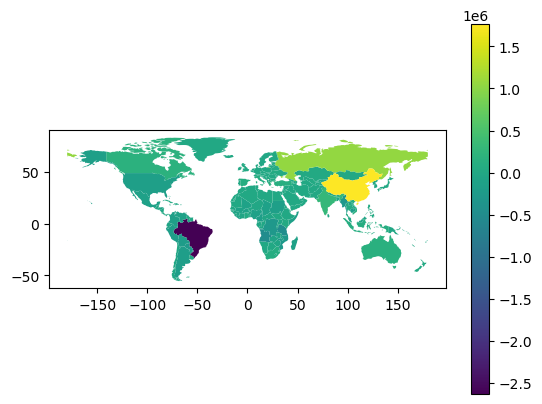

In [209]:
gdf_2019.plot(column="forest_area_change", legend=True)

### 4.2 Error Fixing

4.2.1 Curate Missing Countries on Map

In [210]:
# Try common "name" columns that might exist
name_cols = [c for c in ["ADMIN", "NAME", "SOVEREIGNT", "FORMAL_EN"] if c in gdf_2019.columns]

cols = ["ISO_A3", "WB_A3", "SOV_A3", "ADM0_A3"] + name_cols + ["forest_area_change"]
cols = [c for c in cols if c in gdf_2019.columns]

gdf_2019.loc[gdf_2019["ISO_A3"].isin(["FRA", "NOR"]), cols]

,ISO_A3,WB_A3,SOV_A3,ADM0_A3,ADMIN,NAME,SOVEREIGNT,FORMAL_EN,forest_area_change


In [211]:
print("Rows total:", len(gdf_2019))
print("FRA count:", (gdf_2019["ISO_A3"] == "FRA").sum())
print("NOR count:", (gdf_2019["ISO_A3"] == "NOR").sum())

Rows total: 170
FRA count: 0
NOR count: 0


In [212]:
cols = [c for c in ["ISO_A3", "ADMIN", "NAME", "SOVEREIGNT", "Year", "forest_area_change"] if c in gdf_2019.columns]
gdf_2019.loc[gdf_2019["ISO_A3"].isin(["FRA", "NOR"]), cols]

,ISO_A3,ADMIN,NAME,SOVEREIGNT,Year,forest_area_change


In [213]:
world.loc[
    world["ISO_A3"].isin(["FRA", "NOR"]),
    [c for c in ["ISO_A3", "WB_A3", "ADM0_A3", "SOV_A3", "ADMIN", "NAME", "SOVEREIGNT"] if c in world.columns]
]

,ISO_A3,WB_A3,ADM0_A3,SOV_A3,ADMIN,NAME,SOVEREIGNT


In [214]:
name_col = next((c for c in ["ADMIN", "NAME", "SOVEREIGNT", "FORMAL_EN"] if c in world.columns), None)
print("Using name column:", name_col)

world.loc[
    world[name_col].str.contains("France|Norway", case=False, na=False),
    [c for c in ["ISO_A3", "WB_A3", "ADM0_A3", "SOV_A3", "ADMIN", "NAME", "SOVEREIGNT"] if c in world.columns]
]

Using name column: ADMIN


,ISO_A3,WB_A3,ADM0_A3,SOV_A3,ADMIN,NAME,SOVEREIGNT
21,-99,-99,NOR,NOR,Norway,Norway,Norway
43,-99,FRA,FRA,FR1,France,France,France


In [215]:
# Detect best name column automatically
name_col = next(
    (c for c in ["ADMIN", "NAME", "SOVEREIGNT", "FORMAL_EN"] if c in world.columns),
    None
)

problematic = world.loc[
    world["ISO_A3"] == "-99",
    [c for c in ["ISO_A3", "ADM0_A3", "SOV_A3", "WB_A3", name_col] if c in world.columns]
].sort_values(name_col)

problematic.reset_index(drop=True)

,ISO_A3,ADM0_A3,SOV_A3,WB_A3,ADMIN
0,-99,FRA,FR1,FRA,France
1,-99,KOS,KOS,KSV,Kosovo
2,-99,CYN,CYN,-99,Northern Cyprus
3,-99,NOR,NOR,-99,Norway
4,-99,SOL,SOL,-99,Somaliland


In [216]:
world = world.copy()

world["ISO_A3_CLEAN"] = world["ISO_A3"].astype("string")

# Replace "-99" with ADM0_A3
world.loc[world["ISO_A3_CLEAN"] == "-99", "ISO_A3_CLEAN"] = (
    world.loc[world["ISO_A3_CLEAN"] == "-99", "ADM0_A3"].astype("string")
)

# Optional: ensure only valid 3-letter codes remain
world.loc[world["ISO_A3_CLEAN"].str.len() != 3, "ISO_A3_CLEAN"] = pd.NA

In [217]:
world.loc[
    world["ADMIN"].isin(["France", "Norway"]),
    ["ISO_A3", "ADM0_A3", "ISO_A3_CLEAN", "ADMIN"]
]

,ISO_A3,ADM0_A3,ISO_A3_CLEAN,ADMIN
21,-99,NOR,NOR,Norway
43,-99,FRA,FRA,France


In [218]:
# Check of -99 and missing values after cleaning
print("Count of '-99':", (world["ISO_A3_CLEAN"] == "-99").sum())
print("Missing values:", world["ISO_A3_CLEAN"].isna().sum())

# Check for invalid length
invalid_length = world[
    world["ISO_A3_CLEAN"].notna() &
    (world["ISO_A3_CLEAN"].str.len() != 3)
]

print("Invalid length entries:", len(invalid_length))
invalid_length[["ISO_A3_CLEAN", "ADMIN"]]


# Check for invalid format (not exactly 3 uppercase letters)
invalid_format = world[
    world["ISO_A3_CLEAN"].notna() &
    (~world["ISO_A3_CLEAN"].str.match(r"^[A-Z]{3}$"))
]

print("Invalid format entries:", len(invalid_format))
invalid_format[["ISO_A3_CLEAN", "ADMIN"]]

Count of '-99': 0
Missing values: 0
Invalid length entries: 0
Invalid format entries: 0


,ISO_A3_CLEAN,ADMIN


4.2.2. Curate Missing Countries in Datasets

In [219]:
# Get ISO_A3 codes from the map
iso_map_codes = (
    world["ISO_A3"]
    .dropna()
    .astype(str)
)

iso_map_codes = set(
    iso_map_codes[
        (iso_map_codes.str.len() == 3) &
        (iso_map_codes != "-99")
    ].unique()
)

# Codes that exist in map but not in dataset
missing_in_dataset = iso_map_codes - all_codes

print("ISO_A3 codes in map but NOT in dataset:")
print(missing_in_dataset)
print(f"Count: {len(missing_in_dataset)}")

ISO_A3 codes in map but NOT in dataset:
{'ATA', 'TWN'}
Count: 2


In [220]:
(panel_df["Code"].astype(str) == "TWN").sum()

np.int64(0)

In [221]:
taiwan_rows = panel_df.loc[
    panel_df["Entity"].astype(str).str.contains("taiwan", case=False, na=False),
    ["Entity", "Code"]
].drop_duplicates().sort_values(["Code", "Entity"])

taiwan_rows

,Entity,Code


In [222]:
patterns = ["taiwan", "province of china", "chinese taipei", "taipei"]

alt_rows = panel_df.loc[
    panel_df["Entity"].astype(str).str.contains("|".join(patterns), case=False, na=False),
    ["Entity", "Code"]
].drop_duplicates().sort_values(["Code", "Entity"])

alt_rows

,Entity,Code


In [223]:
DOWNLOADS = Path("..") / "downloads"

# ---- List of dataset filenames ----
datasets = [
    "forest_area_change.csv",
    "annual_deforestation.csv",
    "land_protected.csv",
    "land_degraded.csv",
    "mountain_ecosystems.csv",
]

patterns = ["taiwan", "antarctica", "province of china", "chinese taipei", "taipei"]
pattern = "|".join(patterns)

for filename in datasets:
    df = pd.read_csv(DOWNLOADS / filename)

    hits = df.loc[
        df["Entity"].astype(str).str.contains(pattern, case=False, na=False),
        ["Entity", "Code"]
    ].drop_duplicates()

    print(f"\n{filename} → matches: {len(hits)}")
    if not hits.empty:
        print(hits.to_string(index=False))


forest_area_change.csv → matches: 0

annual_deforestation.csv → matches: 0

land_protected.csv → matches: 0

land_degraded.csv → matches: 0

mountain_ecosystems.csv → matches: 0


## **5. Final Function**

In [224]:
from __future__ import annotations

import geopandas as gpd
import pandas as pd


def merge_map_with_panel(
    world: gpd.GeoDataFrame,
    panel_df: pd.DataFrame,
    map_key: str = "ISO_A3_CLEAN",
) -> gpd.GeoDataFrame:
    
    # Validate required structure (fail fast with a clear error message) 
    required_cols = {"Code", "Year"}
    missing_cols = required_cols - set(panel_df.columns)
    if missing_cols:
        raise ValueError(
            f"panel_df missing required columns: {sorted(missing_cols)}"
        )

    if map_key not in world.columns:
        raise KeyError(
            f"world does not contain map_key column '{map_key}'"
        )

    # Work on copies to keep function safer to reuse and easier to test.
    world_copy = world.copy()
    panel_copy = panel_df.copy()

    # Normalize join key types to ensure consistent matching during merge 
    world_copy[map_key] = world_copy[map_key].astype(str)
    panel_copy["Code"] = panel_copy["Code"].astype(str)

    #  Merge with the map on the left to preserve geometries 
    merged = world_copy.merge(
        panel_copy,
        how="left",
        left_on=map_key,   # Cleaned ISO3 version in the map
        right_on="Code",  
    )

    # Ensure the result is a GeoDataFrame with correct geometry
    return gpd.GeoDataFrame(merged, geometry="geometry", crs=world.crs)